In [ ]:
pip install numpy pandas matplotlib scikit-learn



In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sklearn
import copy
import math


In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)


(20640, 8) (20640,)


In [9]:
print(housing.DESCR) 


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

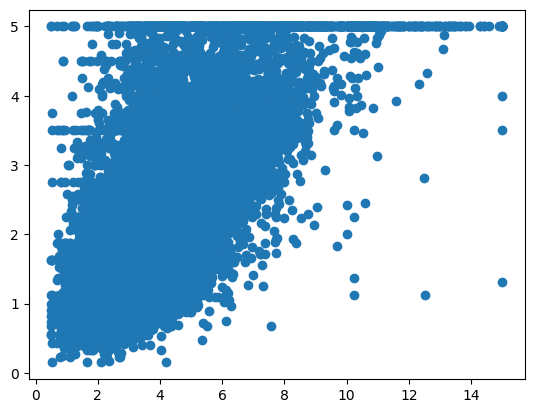

In [12]:
plt.scatter(housing.data[:,0], housing.target)
plt.show()

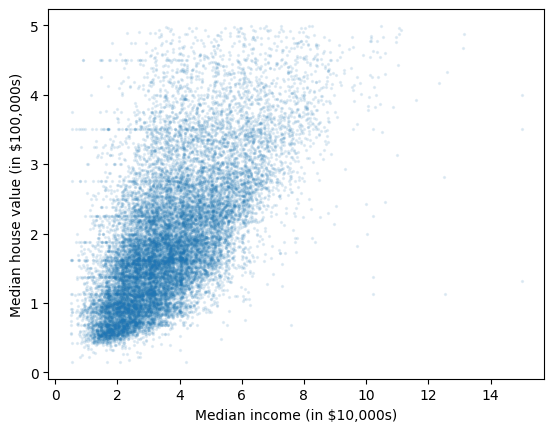

(19648,) (19648,)


In [32]:
income_x = []
prices_y = []
mask = housing.target < 5
income_x = housing.data[mask, 0]
prices_y = housing.target[mask]

plt.scatter(income_x, prices_y, s=2, alpha=0.1)
plt.xlabel("Median income (in $10,000s)")
plt.ylabel("Median house value (in $100,000s)")
plt.show()

print(income_x.shape, prices_y.shape)

In [33]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(income_x, prices_y, test_size=0.20)

In [35]:
def compute_cost(x, y, w, b):
    """
    Computes the cost (mean squared error / 2) for linear regression.

    Args:
        x (ndarray): Shape (m,) input feature (median income)
        y (ndarray): Shape (m,) target values (median house value)
        w, b (scalar): model parameters

    Returns:
        total_cost (float): cost of using w, b to fit x and y
    """
    m = x.shape[0]
    f_wb = w * x + b

    cost_sum = 0
    for i in range(m):
        squared_error = (f_wb[i] - y[i]) ** 2
        cost_sum += squared_error

    total_cost = cost_sum / (2 * m)
    return total_cost

In [36]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradients of the cost with respect to w and b.

    Args:
        x (ndarray): Shape (m,) input feature (median income)
        y (ndarray): Shape (m,) target values (median house value)
        w, b (scalar): model parameters

    Returns:
        dj_dw (scalar): gradient of the cost with respect to w
        dj_db (scalar): gradient of the cost with respect to b
    """
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        error_i = f_wb_i - y[i]

        dj_dw += error_i * x[i]
        dj_db += error_i

    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [ ]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradients of the cost with respect to w and b.

    Args:
        x (ndarray): Shape (m,) input feature (median income)
        y (ndarray): Shape (m,) target values (median house value)
        w, b (scalar): model parameters

    Returns:
        dj_dw (scalar): gradient of the cost with respect to w
        dj_db (scalar): gradient of the cost with respect to b
    """
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        error_i = f_wb_i - y[i]

        dj_dw += error_i * x[i]
        dj_db += error_i

    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [44]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

In [45]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     1.69   
Iteration  150: Cost     0.28   
Iteration  300: Cost     0.28   
Iteration  450: Cost     0.27   
Iteration  600: Cost     0.27   
Iteration  750: Cost     0.27   
Iteration  900: Cost     0.27   
Iteration 1050: Cost     0.27   
Iteration 1200: Cost     0.27   
Iteration 1350: Cost     0.27   
w,b found by gradient descent: 0.4096479140120309 0.4075827702263997


In [46]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Size')

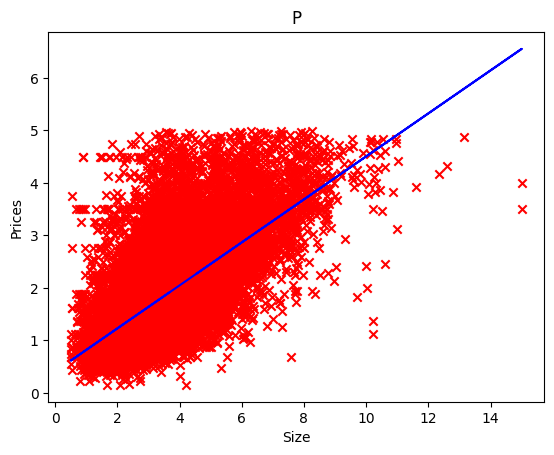

In [47]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("P")
# Set the y-axis label
plt.ylabel('Prices')
# Set the x-axis label
plt.xlabel('Size')